# Glossary Formatter

This notebook parses the glossary HTML file into structured tables and exports TSV files to the outputs directory.

Exports:
- outputs/glossary/glossary_extracted.tsv
- outputs/glossary/glossary_examples_long.tsv
- outputs/glossary/glossary_group_metrics.tsv

In [1]:
# ===========================================================================
# DEPRECATED: This cell uses the HTML glossary source.
# See the new implementation below that parses glossary.md instead.
# ===========================================================================

from __future__ import annotations

import html
import re
from pathlib import Path
from urllib.parse import unquote

import matplotlib.pyplot as plt
import pandas as pd

WORKDIR = Path.cwd()
if not (WORKDIR / 'data').exists():
    WORKDIR = WORKDIR.parent
GLOSSARY_HTML_PATH = WORKDIR / 'data' / 'glossary.html'
OUTPUT_DIR = WORKDIR / 'outputs' / 'glossary'
OUTPUT_EXTRACTED = OUTPUT_DIR / 'glossary_extracted.tsv'
OUTPUT_EXAMPLES_LONG = OUTPUT_DIR / 'glossary_examples_long.tsv'
OUTPUT_GROUP_METRICS = OUTPUT_DIR / 'glossary_group_metrics.tsv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GLOSSARY_HTML_PATH


PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/data/glossary.html')

In [2]:
# ===========================================================================
# DEPRECATED: parse_glossary() parses the HTML source.
# See parse_glossary_md() in the new implementation below.
# ===========================================================================

def strip_tags(text: str) -> str:
    return html.unescape(re.sub(r'<[^>]+>', '', text))


def normalize_text(text: str) -> str:
    text = text.replace('\\', '\n')
    text = text.replace('\r', '\n')
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'[\t ]+', ' ', text)
    return text.strip()


def parse_label_value(blob: str, label: str) -> str:
    pattern = rf'_{re.escape(label)}_:\s*(.*?)(?=(?:\n\s*_[^_]+_:\s*)|$)'
    match = re.search(pattern, blob, flags=re.S)
    if not match:
        return ''
    return normalize_text(match.group(1))


def extract_first_link(blob: str) -> str:
    md_match = re.search(r'\]\((https?://[^)]+)\)', blob)
    if md_match:
        return unquote(md_match.group(1).strip())
    href_match = re.search(r'href="([^"]+)"', blob)
    if href_match:
        return unquote(href_match.group(1).strip())
    return ''


def drop_intro_line(text: str, startswith: str) -> str:
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if lines and lines[0].startswith(startswith):
        lines = lines[1:]
    return normalize_text('\n'.join(lines))


def parse_glossary(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    raw = path.read_text(encoding='utf-8', errors='ignore')

    article_match = re.search(
        r'<article[^>]+id="glossary-page-items"[^>]*>(.*?)</article>',
        raw,
        flags=re.S,
    )
    article_html = article_match.group(1) if article_match else raw

    blocks = re.findall(r'<div>\s*(.*?)\s*</div>', article_html, flags=re.S)

    term_rows: list[dict] = []
    example_rows: list[dict] = []

    for block in blocks:
        if '<dt>' not in block:
            continue

        term_match = re.search(r'<dfn[^>]*>\s*<a[^>]*>(.*?)</a>', block, flags=re.S)
        term = normalize_text(strip_tags(term_match.group(1))) if term_match else ''

        dd_chunks = re.findall(r'<dd>(.*?)</dd>', block, flags=re.S)
        dd_clean = [normalize_text(strip_tags(c)) for c in dd_chunks]

        surface_forms = ''
        persona = ''
        covert_meaning = ''
        dogwhistle_type = ''
        register = ''
        description = ''
        description_source = ''

        examples: list[str] = []
        example_sources: list[str] = []
        example_speakers: list[str] = []
        example_dates: list[str] = []

        for raw_chunk, clean_chunk in zip(dd_chunks, dd_clean):
            if '_Surface forms_:' in raw_chunk:
                surface_forms = parse_label_value(clean_chunk, 'Surface forms')
            elif '_Persona/In-Group_:' in raw_chunk:
                persona = parse_label_value(clean_chunk, 'Persona/In-Group')
                covert_meaning = parse_label_value(clean_chunk, 'Covert (in-group) meaning')
                dogwhistle_type = parse_label_value(clean_chunk, 'Type')
                register = parse_label_value(clean_chunk, 'Register')
            elif 'Description (from' in raw_chunk:
                description_source = extract_first_link(raw_chunk)
                description = drop_intro_line(clean_chunk, 'Description (from')
            elif 'Example context (in' in raw_chunk:
                source_url = extract_first_link(raw_chunk)
                speaker = parse_label_value(clean_chunk, 'Speaker')
                date = parse_label_value(clean_chunk, 'Date')

                example_text = drop_intro_line(clean_chunk, 'Example context (in')
                example_text = re.sub(r'_Speaker_:\s*.*$', '', example_text, flags=re.S).strip()
                example_text = re.sub(r'_Date_:\s*.*$', '', example_text, flags=re.S).strip()

                if example_text:
                    examples.append(example_text)
                    example_sources.append(source_url)
                    if speaker:
                        example_speakers.append(speaker)
                    if date:
                        example_dates.append(date)

                    example_rows.append(
                        {
                            'term': term,
                            'persona_in_group': persona,
                            'type': dogwhistle_type,
                            'register': register,
                            'example_text': example_text,
                            'example_source': source_url,
                            'example_speaker': speaker,
                            'example_date': date,
                        }
                    )

        term_rows.append(
            {
                'term': term,
                'surface_forms': surface_forms,
                'persona_in_group': persona,
                'covert_meaning': covert_meaning,
                'type': dogwhistle_type,
                'register': register,
                'description': description,
                'description_source': description_source,
                'example_count': len(examples),
                'examples': ' || '.join(examples),
                'example_sources': ' ; '.join([s for s in example_sources if s]),
                'example_speakers': ' ; '.join(example_speakers),
                'example_dates': ' ; '.join(example_dates),
            }
        )

    return pd.DataFrame(term_rows), pd.DataFrame(example_rows)


extracted_df, examples_long_df = parse_glossary(GLOSSARY_HTML_PATH)

extracted_df.to_csv(OUTPUT_EXTRACTED, sep='\t', index=False)
examples_long_df.to_csv(OUTPUT_EXAMPLES_LONG, sep='\t', index=False)

print(f'Wrote {len(extracted_df):,} term rows to {OUTPUT_EXTRACTED}')
print(f'Wrote {len(examples_long_df):,} example rows to {OUTPUT_EXAMPLES_LONG}')
extracted_df.head(5)


Wrote 340 term rows to /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/glossary/glossary_extracted.tsv
Wrote 340 example rows to /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/glossary/glossary_examples_long.tsv


,term,surface_forms,persona_in_group,covert_meaning,type,register,description,description_source,example_count,examples,example_sources,example_speakers,example_dates
0,#GenderWooWoo,#GenderWooWoo; #genderwoowoo; gender woo woo,transphobic,Trans people want to escape reality,persona signal (shared culture),Informal/Online,"A reactionary term, which gained traction in m...",https://rationalwiki.org/wiki/TERF_glossary,1,"""So it’s #GenderWooWoo day and I’d like to sha...",https://web.archive.org/web/20221126161023/htt...,Anonymous,"May 21, 2020"
1,#Milk,#Milk; #milk; #MilkTwitter,white supremacist,White supremacist signal where milk is allegor...,persona signal (self-referential),Informal/Online,"For members of the far-right, dairy milk repre...",https://link.springer.com/chapter/10.1007/978-...,1,"""I'm very proud of my mutant power of digestin...",https://theconversation.com/how-the-alt-right-...,Anonymous,"May 30, 2017"
2,#WomenWontWheesht,#WomenWontWheesht; #womenwontwheesht; women wo...,transphobic,Trans people are silencing cis women,persona signal (shared culture),Informal/Online,A hashtag that first emerged among Scottish TE...,https://rationalwiki.org/wiki/TERF_glossary,1,"""I had the best day yesterday. Thank you ⁦@jk_...",http://web.archive.org/web/20220411085507/http...,Joanna Cherry (Scottish Member of Parliament),"April 11, 2022"
3,109,109;110,antisemitic,Antisemitic signal that is a reference to numb...,persona signal (symbol),Informal/Online,109 stands for the 109 locations that Jews wer...,https://rationalwiki.org/wiki/Alt-right_glossary,1,"""""Wow 109 countries, and they consider us as c...",https://twitter.com/ZNNpatriot/status/15599091...,Anonymous,"August 17, 2022"
4,1290,1290; 1290 AD,antisemitic,Antisemitic signal that is a reference to the ...,persona signal (symbol),Informal/Online,1290 was the year that Jews were expelled from...,https://rationalwiki.org/wiki/Alt-right_glossary,1,"""I think that ur Marxist police state apparatu...",https://twitter.com/TurnerDiaries/status/52582...,Anonymous,"October 24, 2014"


In [3]:
# ===========================================================================
# DEPRECATED: See updated group metrics in the new implementation below.
# ===========================================================================

def aggregate_group_metrics(df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['persona_in_group', 'type', 'register']
    metrics = (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            term_count=('term', 'count'),
            unique_term_count=('term', 'nunique'),
            total_examples=('example_count', 'sum'),
            avg_examples_per_term=('example_count', 'mean'),
        )
        .sort_values(['total_examples', 'term_count'], ascending=False)
    )
    metrics['avg_examples_per_term'] = metrics['avg_examples_per_term'].round(3)
    return metrics


group_metrics_df = aggregate_group_metrics(extracted_df)
group_metrics_df.to_csv(OUTPUT_GROUP_METRICS, sep='\t', index=False)

print(f'Wrote {len(group_metrics_df):,} grouped rows to {OUTPUT_GROUP_METRICS}')
group_metrics_df.head(15)


Wrote 96 grouped rows to /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/glossary/glossary_group_metrics.tsv


,persona_in_group,type,register,term_count,unique_term_count,total_examples,avg_examples_per_term
55,racist,concept (policy),Formal/Offline,26,26,26,1.0
36,antisemitic,stereotype-based target group label,Formal/Offline,22,22,22,1.0
93,white supremacist,persona signal (symbol),Informal/Online,21,21,21,1.0
65,racist,stereotype-based target group label,Formal/Offline,12,12,12,1.0
71,transphobic,concept (values),Formal/Offline,11,11,11,1.0
34,antisemitic,stereotype-based descriptor,Formal/Offline,10,10,10,1.0
79,transphobic,persona signal (symbol),Informal/Online,9,9,9,1.0
83,transphobic,stereotype-based target group label,Informal/Online,9,9,9,1.0
56,racist,concept (values),Formal/Offline,8,8,8,1.0
75,transphobic,persona signal (self-referential),Formal/Offline,8,8,8,1.0


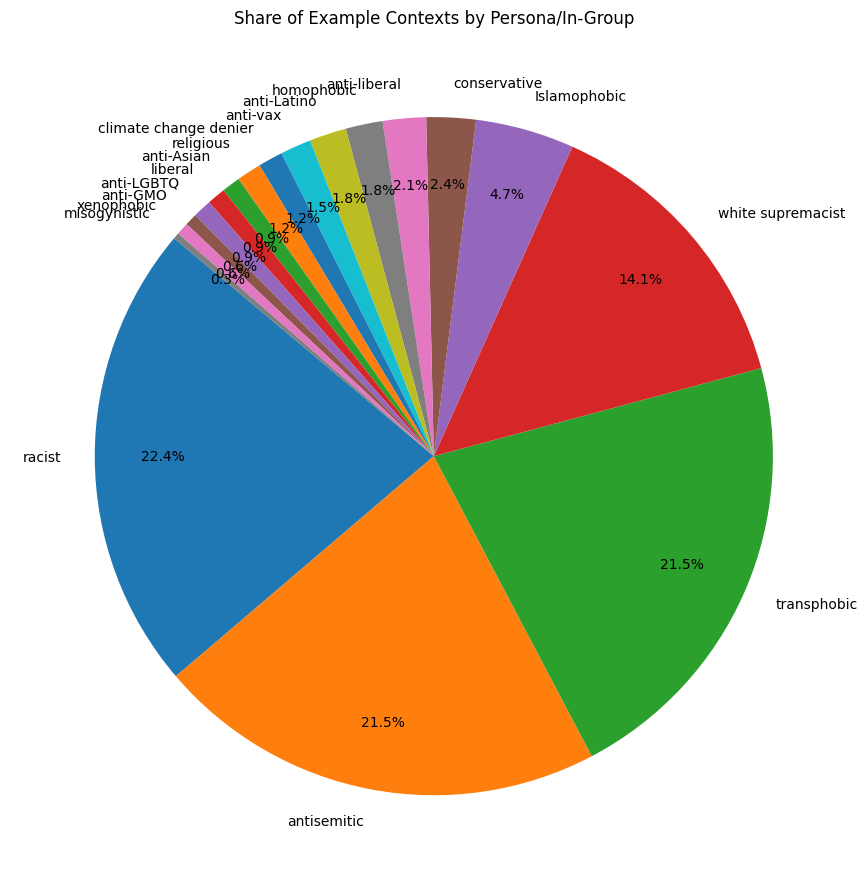

,example_count
racist,76
antisemitic,73
transphobic,73
white supremacist,48
Islamophobic,16
conservative,8
anti-liberal,7
homophobic,6
anti-Latino,6
anti-vax,5


In [4]:
# ===========================================================================
# DEPRECATED: See updated visualization in the new implementation below.
# ===========================================================================

examples_by_group = (
    extracted_df.groupby('persona_in_group', dropna=False)['example_count']
    .sum()
    .sort_values(ascending=False)
)

examples_by_group.index = [
    idx if isinstance(idx, str) and idx.strip() else 'Unknown'
    for idx in examples_by_group.index
]

plt.figure(figsize=(9, 9))
plt.pie(
    examples_by_group.values,
    labels=examples_by_group.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
)
plt.title('Share of Example Contexts by Persona/In-Group')
plt.tight_layout()
plt.show()

examples_by_group.to_frame('example_count')


---

## New Implementation — Parsing `glossary.md`

Parses `data/glossary.md` and writes a single consolidated TSV:

- `outputs/glossary/glossary.tsv`

Summary statistics and the example-share chart are computed below without writing additional files.


In [5]:
from __future__ import annotations

import re
from pathlib import Path
from urllib.parse import unquote

import matplotlib.pyplot as plt
import pandas as pd

WORKDIR = Path.cwd()
if not (WORKDIR / 'data').exists():
    WORKDIR = WORKDIR.parent
GLOSSARY_MD_PATH = WORKDIR / 'data' / 'glossary.md'
OUTPUT_DIR = WORKDIR / 'outputs' / 'glossary'
OUTPUT_TSV = OUTPUT_DIR / 'glossary.tsv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GLOSSARY_MD_PATH


PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/data/glossary.md')

In [6]:
def _extract_link_url(text: str) -> str:
    m = re.search(r'\]\((https?://[^)]+)\)', text)
    return unquote(m.group(1).strip()) if m else ''


def _parse_label(block: str, label: str) -> str:
    m = re.search(rf'_{re.escape(label)}_:\s*(.*?)(?=\s*_[^_]+_:|$)', block, re.S)
    if not m:
        return ''
    return re.sub(r'\s+', ' ', m.group(1)).strip()


def parse_glossary_md(path: Path) -> pd.DataFrame:
    raw = path.read_text(encoding='utf-8', errors='ignore')
    # Normalize backslash line-continuations (soft-wrap artifacts from HTML source)
    raw = re.sub(r'\\\n\s*', '\n', raw)

    # Split into per-term blocks at each **term** heading
    entries = re.split(r'\n(?=\*\*)', raw)

    rows: list[dict] = []
    for entry in entries:
        term_m = re.match(r'\*\*([^*]+)\*\*', entry.strip())
        if not term_m:
            continue
        term = term_m.group(1).strip()

        sf_m = re.search(r'_Surface forms_:\s*([^\n]+)', entry)
        surface_forms = sf_m.group(1).strip() if sf_m else ''

        persona_block_m = re.search(
            r'_Persona/In-Group_:.*?(?=\nDescription|\nExample|\Z)', entry, re.S
        )
        persona_block = persona_block_m.group(0) if persona_block_m else ''
        persona = _parse_label(persona_block, 'Persona/In-Group')
        covert_meaning = _parse_label(persona_block, 'Covert (in-group) meaning')
        dogwhistle_type = _parse_label(persona_block, 'Type')
        register = _parse_label(persona_block, 'Register')

        desc_header_m = re.search(r'Description \(from [^\n]+', entry)
        description_source = _extract_link_url(desc_header_m.group(0)) if desc_header_m else ''
        desc_body_m = re.search(
            r'Description \(from [^\n]+\n(.*?)(?=\nExample context|\Z)', entry, re.S
        )
        description = (
            re.sub(r'\s+', ' ', desc_body_m.group(1)).strip() if desc_body_m else ''
        )

        examples, ex_sources, ex_speakers, ex_dates = [], [], [], []
        for ex_m in re.finditer(
            r'Example context \(in ([^\n]+)\n(.*?)(?=\nExample context|\Z)', entry, re.S
        ):
            source_url = _extract_link_url(ex_m.group(1))
            body = ex_m.group(2)
            speaker = _parse_label(body, 'Speaker')
            date = _parse_label(body, 'Date')
            ex_text = re.sub(r'_Speaker_:.*', '', body, flags=re.S).strip()
            ex_text = re.sub(r'\s+', ' ', ex_text).strip()
            if ex_text:
                examples.append(ex_text)
                ex_sources.append(source_url)
                ex_speakers.append(speaker)
                ex_dates.append(date)

        rows.append(
            {
                'term': term,
                'surface_forms': surface_forms,
                'persona_in_group': persona,
                'covert_meaning': covert_meaning,
                'type': dogwhistle_type,
                'register': register,
                'description': description,
                'description_source': description_source,
                'example_count': len(examples),
                'examples': ' || '.join(examples),
                'example_sources': ' ; '.join(s for s in ex_sources if s),
                'example_speakers': ' ; '.join(s for s in ex_speakers if s),
                'example_dates': ' ; '.join(s for s in ex_dates if s),
            }
        )

    return pd.DataFrame(rows)


glossary_df = parse_glossary_md(GLOSSARY_MD_PATH)
glossary_df.to_csv(OUTPUT_TSV, sep='\t', index=False)

print(f'Wrote {len(glossary_df):,} term rows  →  {OUTPUT_TSV}')
glossary_df.head(5)


Wrote 340 term rows  →  /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/glossary/glossary.tsv


,term,surface_forms,persona_in_group,covert_meaning,type,register,description,description_source,example_count,examples,example_sources,example_speakers,example_dates
0,abolish birthright citizenship,abolish birthright citizenship; abolition of b...,anti-Latino,We should have fewer Latinos in the US,concept (policy),Formal/Offline,Talk of abolishing birthright citizenship (the...,https://rationalwiki.org/wiki/Code_word,1,"""If we truly love America, we must end birthri...",https://twitter.com/RepMattGaetz/status/134575...,Matt Gaetz (Florida Representative),"January 3, 2021"
1,absent fathers,absent fathers; absentee fathers; absent fathe...,racist,Black men are irresponsible,stereotype-based target group label,Formal/Offline,“Absentee fathers” only seem to come in one co...,https://colorofchange.org/wp-content/uploads/2...,1,"""There are so many things we can talk about. T...",https://theweek.com/articles/552308/deadbeat-b...,Rand Paul (Kentucky Senator),"April 28, 2015"
2,actual woman,actual woman; actual women,transphobic,Transphobic signal that the speaker is a cis w...,persona signal (self-referential),Formal/Offline,"Self-description by TERFs, because they think ...",https://rationalwiki.org/wiki/TERF_glossary,1,"""Lia Thomas was beaten out of the “Woman of Th...",https://twitter.com/TomiLahren/status/15520336...,Tomi Lahren (conservative radio and talk show ...,"July 26, 2022"
3,adult human female,adult human female; adult human females,transphobic,Transphobic signal that the speaker is a cis w...,persona signal (self-referential),Formal/Offline,"Adult human female"" is a slogan and self-ident...",https://rationalwiki.org/wiki/TERF_glossary,1,"""Faintly hysterical at the fact that The Globe...",https://twitter.com/helenlewis/status/15580631...,Helen Lewis (journalist),"August 12, 2022"
4,AFAB trans woman,AFAB trans woman; AFAB transgender woman; AFAB...,transphobic,Transphobic joke that a cis woman can claim to...,humor/mockery/sarcasm,Informal/Online,This can be one of several things: A word sala...,https://rationalwiki.org/wiki/TERF_glossary,1,"""This is stunning and brave, from an assigned ...",https://twitter.com/zaelefty/status/1458648435...,Zach Eliiot (author),"Novermber 10, 2021"


In [7]:
# --- Group metrics summary ---
group_cols = ['persona_in_group', 'type', 'register']
group_metrics = (
    glossary_df.groupby(group_cols, dropna=False, as_index=False)
    .agg(
        term_count=('term', 'count'),
        unique_term_count=('term', 'nunique'),
        total_examples=('example_count', 'sum'),
        avg_examples_per_term=('example_count', 'mean'),
    )
    .sort_values(['total_examples', 'term_count'], ascending=False)
)
group_metrics['avg_examples_per_term'] = group_metrics['avg_examples_per_term'].round(3)

print(f'{len(group_metrics):,} persona/type/register groups')
group_metrics.head(15)


96 persona/type/register groups


,persona_in_group,type,register,term_count,unique_term_count,total_examples,avg_examples_per_term
55,racist,concept (policy),Formal/Offline,26,26,26,1.0
36,antisemitic,stereotype-based target group label,Formal/Offline,22,22,22,1.0
93,white supremacist,persona signal (symbol),Informal/Online,21,21,21,1.0
65,racist,stereotype-based target group label,Formal/Offline,12,12,12,1.0
71,transphobic,concept (values),Formal/Offline,11,11,11,1.0
34,antisemitic,stereotype-based descriptor,Formal/Offline,10,10,10,1.0
79,transphobic,persona signal (symbol),Informal/Online,9,9,9,1.0
83,transphobic,stereotype-based target group label,Informal/Online,9,9,9,1.0
56,racist,concept (values),Formal/Offline,8,8,8,1.0
75,transphobic,persona signal (self-referential),Formal/Offline,8,8,8,1.0


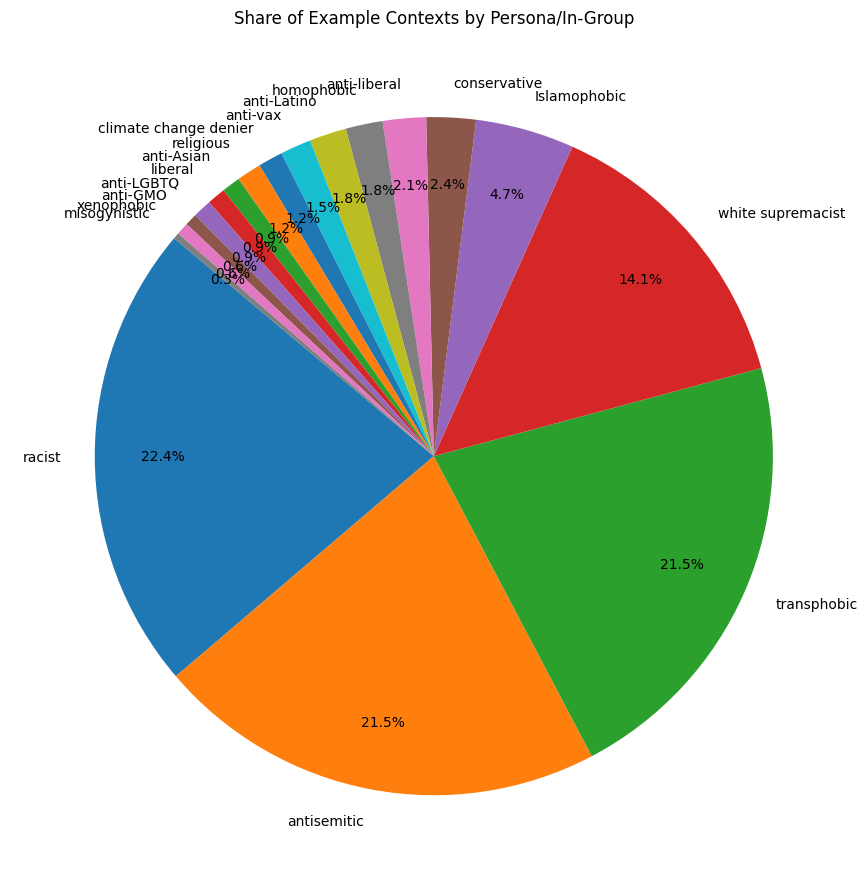

,example_count
racist,76
antisemitic,73
transphobic,73
white supremacist,48
Islamophobic,16
conservative,8
anti-liberal,7
homophobic,6
anti-Latino,6
anti-vax,5


In [8]:
# --- Example-share pie chart by persona/in-group ---
examples_by_group = (
    glossary_df.groupby('persona_in_group', dropna=False)['example_count']
    .sum()
    .sort_values(ascending=False)
)

examples_by_group.index = [
    idx if isinstance(idx, str) and idx.strip() else 'Unknown'
    for idx in examples_by_group.index
]

plt.figure(figsize=(9, 9))
plt.pie(
    examples_by_group.values,
    labels=examples_by_group.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
)
plt.title('Share of Example Contexts by Persona/In-Group')
plt.tight_layout()
plt.show()

examples_by_group.to_frame('example_count')
